In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
data_dir = '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605'
fn_list = glob.glob(os.path.join(data_dir, 'zbest-*.fits'))

In [4]:
fn_list

['/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-2-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-6-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-1-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-7-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-4-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-0-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-5-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-3-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-8-80605.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80605/zbest-9-80605.fits']

In [5]:
zbest = []
for fn in fn_list:
    tmp1 = Table.read(fn, hdu='ZBEST')
    tmp2 = Table.read(fn, hdu='FIBERMAP')
    tmp = join(tmp1, tmp2, keys='TARGETID', metadata_conflicts='silent')
    zbest.append(tmp)
zbest = vstack(zbest)
print(len(zbest))

5000


In [6]:
zbest[:5]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39627652570553150,14542.825838685036,74.26292321574277 .. 6.879264515636245,1.0032956047392658,4.293755486304631e-05,0,7756,GALAXY,,10,479.48880422115326,0,0,2,442,2442,1365,0,35.09210289236488,-5.38557694619921,0.0,0.0,2020.9487,5400.0,36031545798068742,1,TGT,341.90082,-198.45499,0,3400,0.052258214173676154,3,PSF,0.3641944,0.5067979,1.1190605,3505.0718,2485.9739,320.84125,0,,0.0,0.0,0.0,0.0,0.023968648,1.1111243,1.0189291,0.28352743,0.39454508,0.871195,0.28352743,0.39454508,0.871195,0,0.0,0.0,0.0,0.0,S,36031545798068742,0,0,3400,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,341.881,-198.453,0.0007499999999999998,-0.0015,0.0,0.0,8,0.008440971508067066,0.00565685424949238,1365,1365,1
39627652570553175,16772.648281365633,207.06003435544795 .. 11.498602583543246,0.36472508614982446,4.1878840208270296e-05,4,7734,GALAXY,,10,3.409461200237274,0,0,2,441,2441,1387,0,35.0927226165769,-5.423932556928182,0.0,0.0,2020.9487,5400.0,3023656979202,1,TGT,342.0834,-208.37384,0,3000,0.829025211385593,3,REX,0.38831154,0.4974968,1.0144477,3215.1355,2593.6655,262.8109,0,,0.0,0.0,0.0,0.0,0.024509408,2.3942218,0.1458119,0.27532536,0.35274124,0.7192761,0.27532536,0.35274124,0.7192761,0,1.0,0.21078768,0.0,0.0,S,3023656979202,0,0,3000,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,342.061,-208.373,0.0012499999999999998,-0.0007499999999999998,0.0,0.0,8,0.008930285549745877,0.007905694150420948,1387,1387,1
39627652570553308,14520.641379714012,-31.507394914931993 .. -0.3481305956098292,1.1978999988560723,6.515929337907863e-05,0,7750,GALAXY,,10,55.24691241979599,0,0,2,440,2440,1363,0,35.09602370467814,-5.463687695411304,0.0,0.0,2020.9487,5400.0,1374389536002,1,TGT,341.57806,-218.66023,0,3000,0.972041710850576,3,EXP,0.44068575,0.63115567,1.4717416,1091.2917,710.6528,66.37184,0,,0.0,0.0,0.0,0.0,0.024580952,3.7358518,2.1523538,0.11695074,0.16749832,0.39057598,0.11695176,0.1674999,0.3905803,0,1.0,1.5769453,-0.38684034,-0.2378538,S,1374389536002,0,0,3000,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,341.556,-218.656,0.0011250000000000001,-0.0008749999999999999,0.0,0.0,8,0.008507349763586778,0.006809919235938117,1363,1363,1
39627652570554806,15538.595762133598,0.0011770679988563715 .. 0.0,1.9145345112075447,7.53976452231661e-05,0,7737,QSO,,4,30201.477858781815,0,0,2,416,2416,1395,0,35.13856082118093,-5.511215691943534,0.7920557,-0.2884497,2020.9487,5400.0,2359886204742189060,1,TGT,330.6728,-230.5961,0,3400,0.574101755292

In [7]:
# SV1 target bits
bitvalues = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 53, 54, 55, 56, 57, 32, 33, 34, 35, 36, 37, 49, 50, 51, 52, 60, 61, 62]
bitnames = ['LRG', 'ELG', 'QSO', 'LRG_OPT', 'LRG_IR', 'LRG_SV_OPT', 'LRG_SV_IR', 'LOWZ_FILLER', 'ELG_SV_GTOT', 'ELG_SV_GFIB', 'ELG_FDR_GTOT', 'ELG_FDR_GFIB', 'QSO_COLOR_4PASS', 'QSO_RF_4PASS', 'QSO_COLOR_8PASS', 'QSO_RF_8PASS', 'QSO_HZ_F', 'QSO_Z5', 'LRG_OPT_NORTH', 'LRG_IR_NORTH', 'LRG_SV_OPT_NORTH', 'LRG_SV_IR_NORTH', 'LOWZ_FILLER_NORTH', 'LRG_OPT_SOUTH', 'LRG_IR_SOUTH', 'LRG_SV_OPT_SOUTH', 'LRG_SV_IR_SOUTH', 'LOWZ_FILLER_SOUTH', 'ELG_SV_GTOT_NORTH', 'ELG_SV_GFIB_NORTH', 'ELG_FDR_GTOT_NORTH', 'ELG_FDR_GFIB_NORTH', 'ELG_SV_GTOT_SOUTH', 'ELG_SV_GFIB_SOUTH', 'ELG_FDR_GTOT_SOUTH', 'ELG_FDR_GFIB_SOUTH', 'QSO_COLOR_4PASS_NORTH', 'QSO_RF_4PASS_NORTH', 'QSO_COLOR_8PASS_NORTH', 'QSO_RF_8PASS_NORTH', 'QSO_HZ_F_NORTH', 'QSO_Z5_NORTH', 'QSO_COLOR_4PASS_SOUTH', 'QSO_RF_4PASS_SOUTH', 'QSO_COLOR_8PASS_SOUTH', 'QSO_RF_8PASS_SOUTH', 'QSO_HZ_F_SOUTH', 'QSO_Z5_SOUTH', 'SKY', 'STD_FAINT', 'STD_WD', 'STD_BRIGHT', 'BAD_SKY', 'SUPP_SKY', 'NO_TARGET', 'BRIGHT_OBJECT', 'IN_BRIGHT_OBJECT', 'NEAR_BRIGHT_OBJECT', 'BGS_ANY', 'MWS_ANY', 'SCND_ANY']

def bitmask_summary(mask_values, names, bits):
    mask_values = np.array(mask_values, dtype=np.uint64)
    t = Table()
    t['name'] = names
    t['bit'] = bits
    t['count'] = 0
    for index in range(len(bits)):
        bit = bits[index]
        t['count'][index] = np.sum(mask_values & (2**bit)>0)
    t['frac (%)'] = t['count']/len(mask_values)*100
    t['frac (%)'].format = "%.3f"
    return t

In [8]:
t = bitmask_summary(zbest['SV1_DESI_TARGET'], bitnames, bitvalues)
t.pprint(max_lines=-1)

         name         bit count frac (%)
--------------------- --- ----- --------
                  LRG   0  2117   42.340
                  ELG   1  1341   26.820
                  QSO   2  1428   28.560
              LRG_OPT   3   567   11.340
               LRG_IR   4   590   11.800
           LRG_SV_OPT   5  1610   32.200
            LRG_SV_IR   6  1802   36.040
          LOWZ_FILLER   7     0    0.000
          ELG_SV_GTOT   8  1078   21.560
          ELG_SV_GFIB   9  1228   24.560
         ELG_FDR_GTOT  10   559   11.180
         ELG_FDR_GFIB  11   675   13.500
      QSO_COLOR_4PASS  12   359    7.180
         QSO_RF_4PASS  13   713   14.260
      QSO_COLOR_8PASS  14   248    4.960
         QSO_RF_8PASS  15   419    8.380
             QSO_HZ_F  16   236    4.720
               QSO_Z5  17    25    0.500
        LRG_OPT_NORTH  18     0    0.000
         LRG_IR_NORTH  19     0    0.000
     LRG_SV_OPT_NORTH  20     0    0.000
      LRG_SV_IR_NORTH  21     0    0.000
    LOWZ_FILLER_

In [9]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

ts_sky = (zbest['DESI_TARGET'] & 2**32>0)
print(np.sum(ts_sky))

567
590
2117

1428
45
4
800


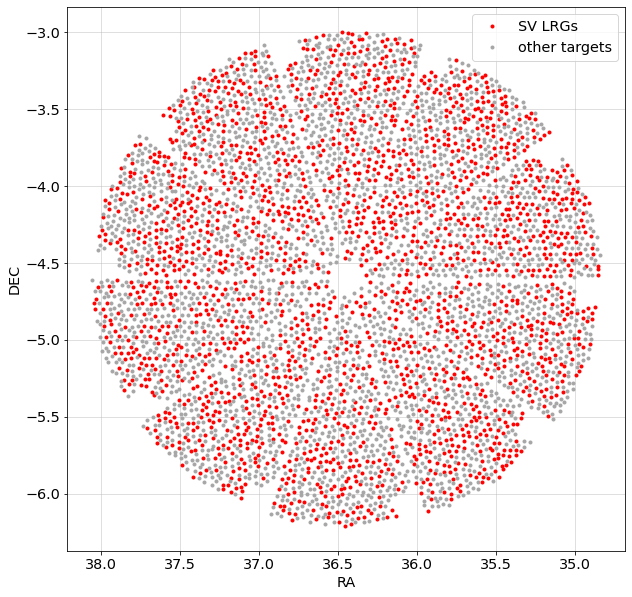

In [10]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [11]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']!=0
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[~mask]

# Remove "no data" fibers
nodata = zbest['ZWARN'] & 2**9>0
print(np.sum(nodata), np.sum(~nodata), np.sum(nodata)/len(nodata))
zbest = zbest[~nodata]

print(len(zbest))

828 4172 0.1656
0 4172 0.0
4172


In [12]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

462
489
1745

1207
38
3


In [13]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

2 0.004329004329004329
2 0.00408997955010225
45 0.025787965616045846


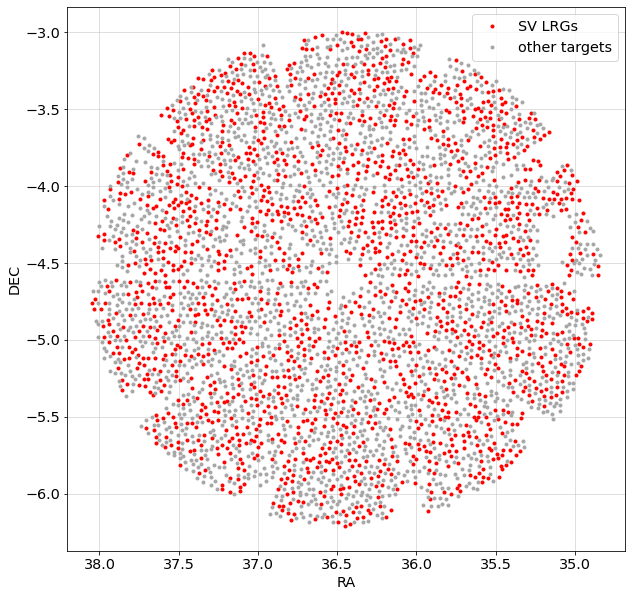

In [14]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

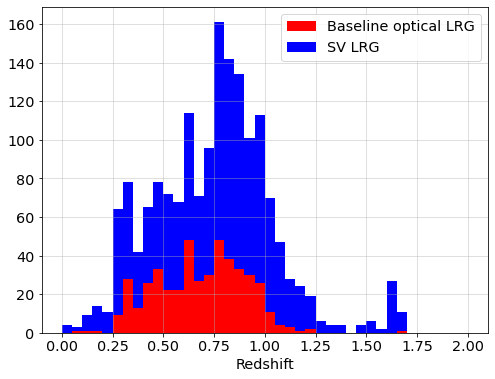

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


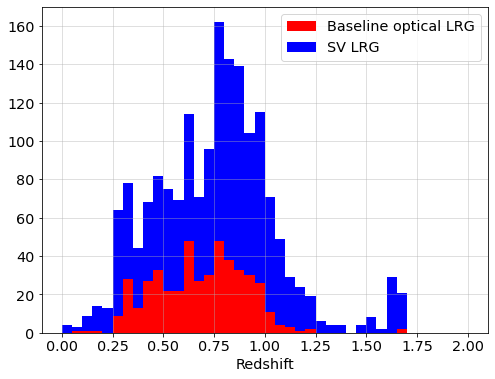

In [16]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

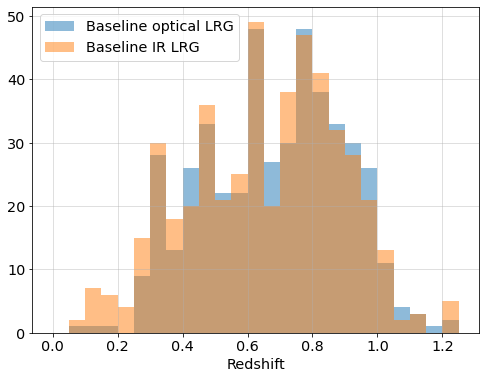

In [17]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline optical LRG'], alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline IR LRG'], alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

--------
# Stellar contamination

In [18]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,455,98.9
QSO,3,0.7
STAR,2,0.4


In [19]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,473,97.1
QSO,13,2.7
STAR,1,0.2


In [20]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,1653,97.2
QSO,37,2.2
STAR,10,0.6


In [21]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [22]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

10
2


In [23]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

2
0


In [24]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39627670631226896,36362.73939551854,-1317.7936643364637 .. 0.0,-5.372710604089739e-06,2.2379202013981895e-06,0,7758,STAR,M,5,27548.018606047393,0,0,2,434,2434,1474,0,35.05384352700487,-4.7923116410533755,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,348.86023,-47.9213,0,3200,0.2652412495250299,1,PSF,0.46197674,2.220406,10.72021,1610.3171,743.8867,139.18456,0,,0.0,0.0,0.0,0.0,0.020624584,23.675903,24.178036,0.35984418,1.7295247,8.350215,4.3350196,16.13527,57.380722,0,0.0,0.0,0.0,0.0,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,348.866,-47.947,-0.003,-0.003125,0.0,0.0,8,0.005408326913195984,0.005396758286230726,1474,1474,1
39627682698239034,19010.653957832765,-152.70015758226987 .. 0.0,-0.00011614658128754453,1.70285902269577e-05,0,7758,STAR,M,5,817.5570240726956,0,0,4,30,4030,2121,0,36.24237925562549,-4.235496909216657,0.0,0.0,2020.9487,5400.0,125829241,1,TGT,49.848007,89.11508,0,3200,0.548927455327992,1,PSF,0.031197298,0.29309866,3.583516,3408.5273,1872.7367,197.51434,0,,0.0,0.0,0.0,0.0,0.027307762,19.917841,16.282894,0.024253543,0.22786207,2.785913,0.269311,1.181051,4.9547133,0,0.0,0.0,0.0,0.0,S,125829241,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,49.825,89.118,-0.000125,0.001,0.0,0.0,8,0.00544288526426931,0.0052915026221291815,2121,2121,1
39627706819675786,16983.075496122976,-546.8814484555577 .. 0.0,-0.0001772081235128468,4.3202546357792346e-06,0,7759,STAR,M,5,10799.930738701682,0,0,4,434,4434,2415,0,35.84730506821909,-3.345163799378597,0.0,0.0,2020.9487,5400.0,33554465,1,TGT,150.07726,315.26718,0,3200,0.1483808684268445,1,PSF,1.5219616,5.4206266,20.066126,2702.1418,1253.8477,204.76404,2490322987134005632,G2,20.58857,21.438261,19.38615,0.0,0.024331098,31.815117,21.84226,1.185399,4.221924,15.628756,1.185399,4.221924,15.628756,768,0.0,0.0,0.0,0.0,S,33554465,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,150.072,315.24,-0.0008750000000000002,0.0015,0.0,0.0,8,0.007219764539096825,0.0045825756949558405,2415,2415,1
39627706823876067,53303.13063318622,-1383.6259146838308 .. 0.0,4.8071887349033384e-05,2.524757122486671e-06,0,7730,STAR,M,5,15713.60577004063,0,0,5,318,5318,2772,0,36.2703452553665,-3.3047022733628513,0.0,0.0,2020.9487,5400.0,67108929,1,TGT,43.918114,324.10693,0,3200,0.34169415373909573,1,REX,0.43828705,2.9654605,8.628148,3075.245,1483.031,186.79893,0,,0.0,0.0,0.0,0.0,0.024084354,29.999794,11.799967,0.31653005,2.14165,6.231232,0.5714162,3.13

In [25]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2'])
    zbest['gmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_G'])/zbest['FLUX_G']
    zbest['rmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_R'])/zbest['FLUX_R']
    zbest['zmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_Z'])/zbest['FLUX_Z']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z'])

zbest['z_phot'] = zbest['Z']

458


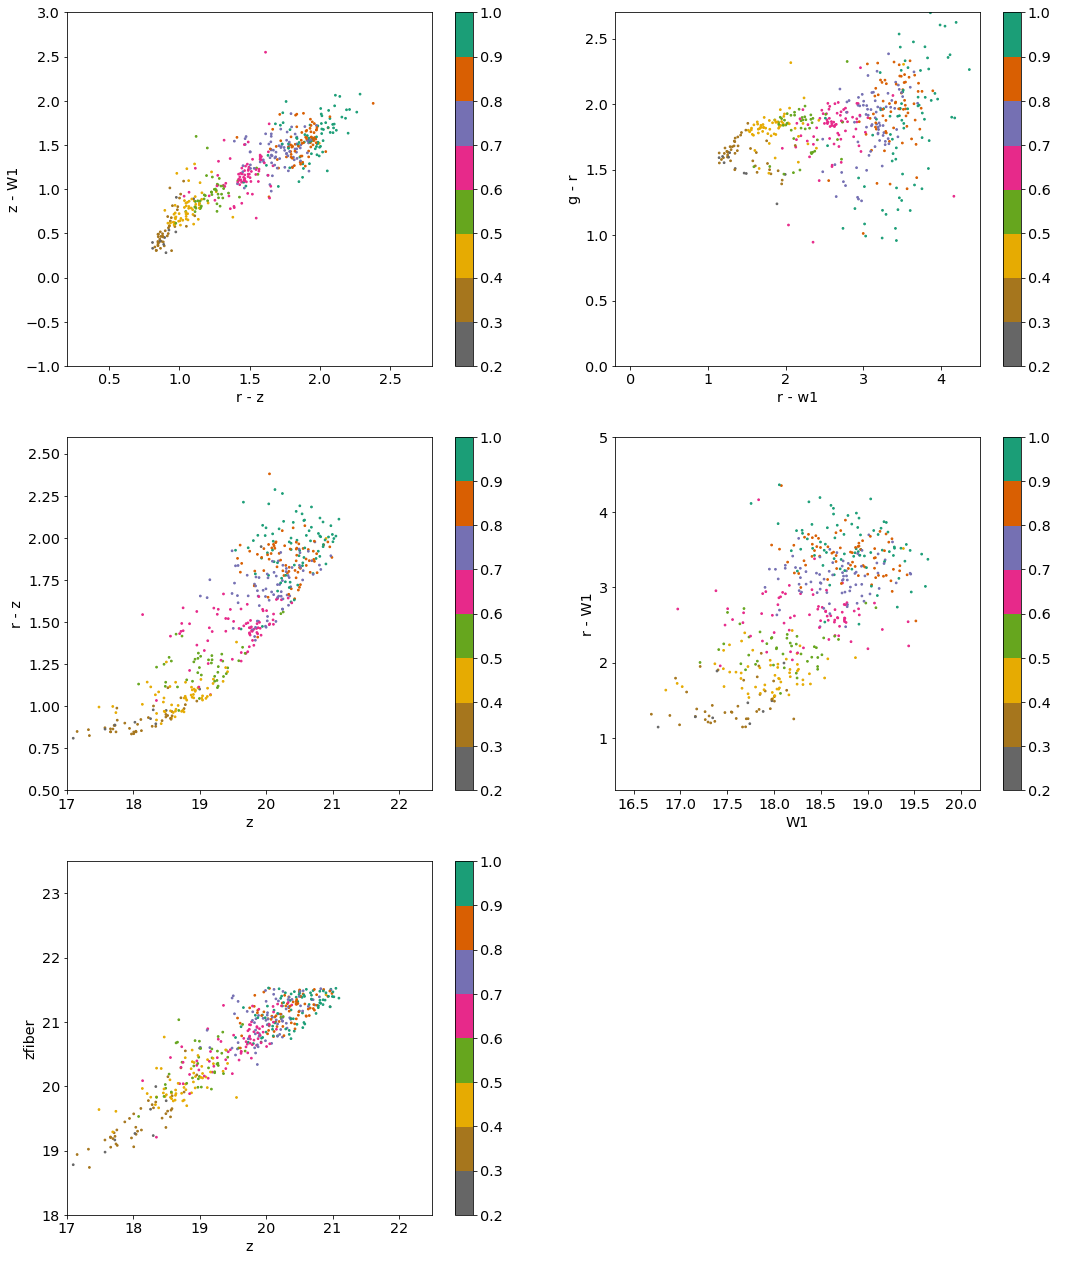

In [27]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

2


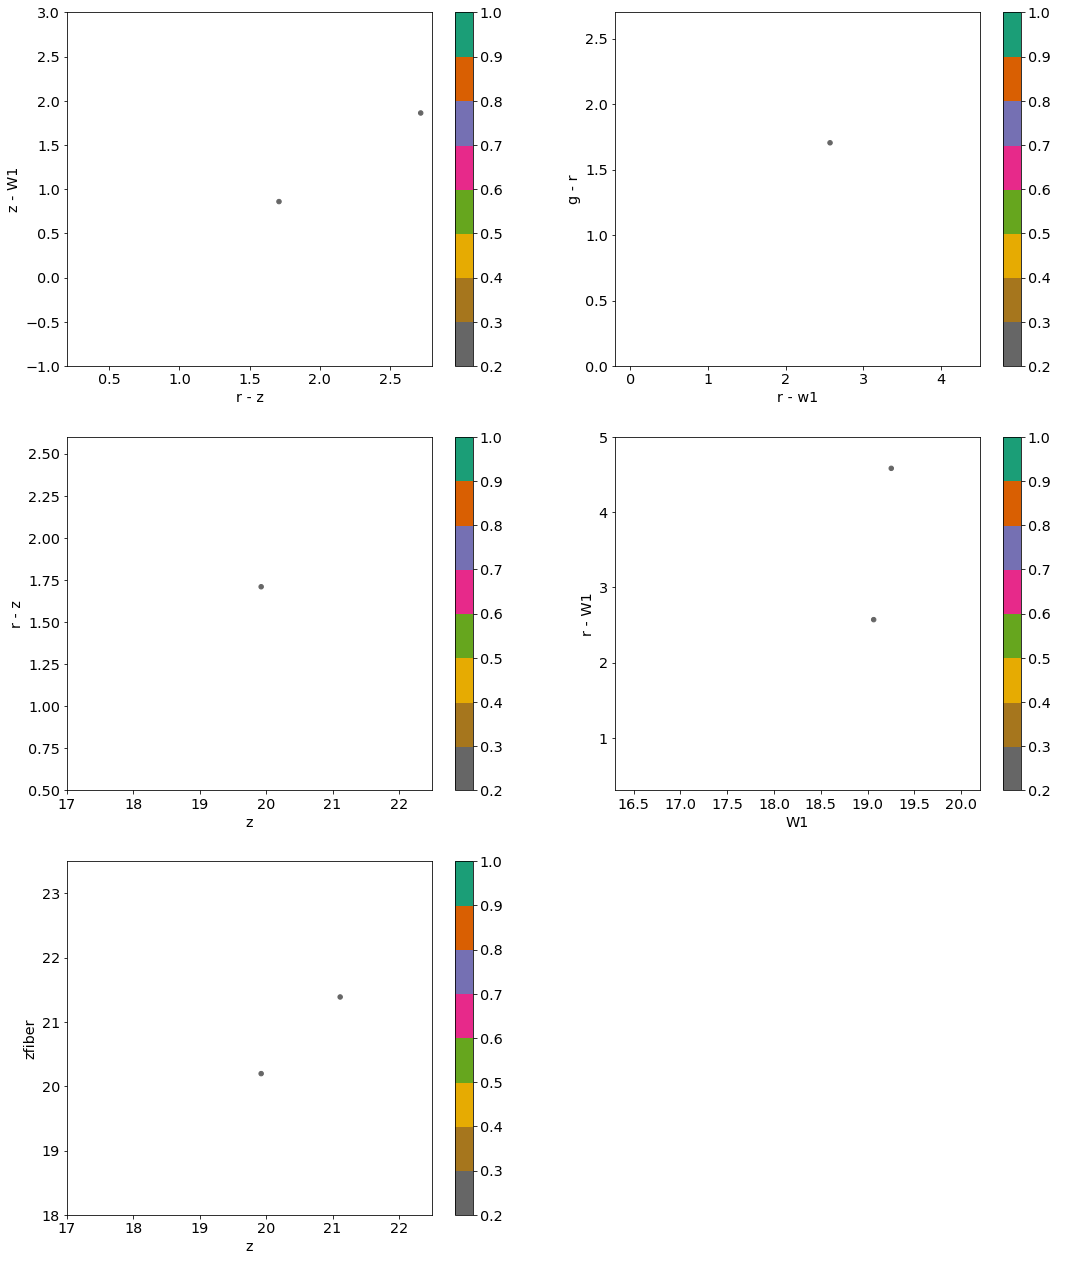

In [28]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

1690


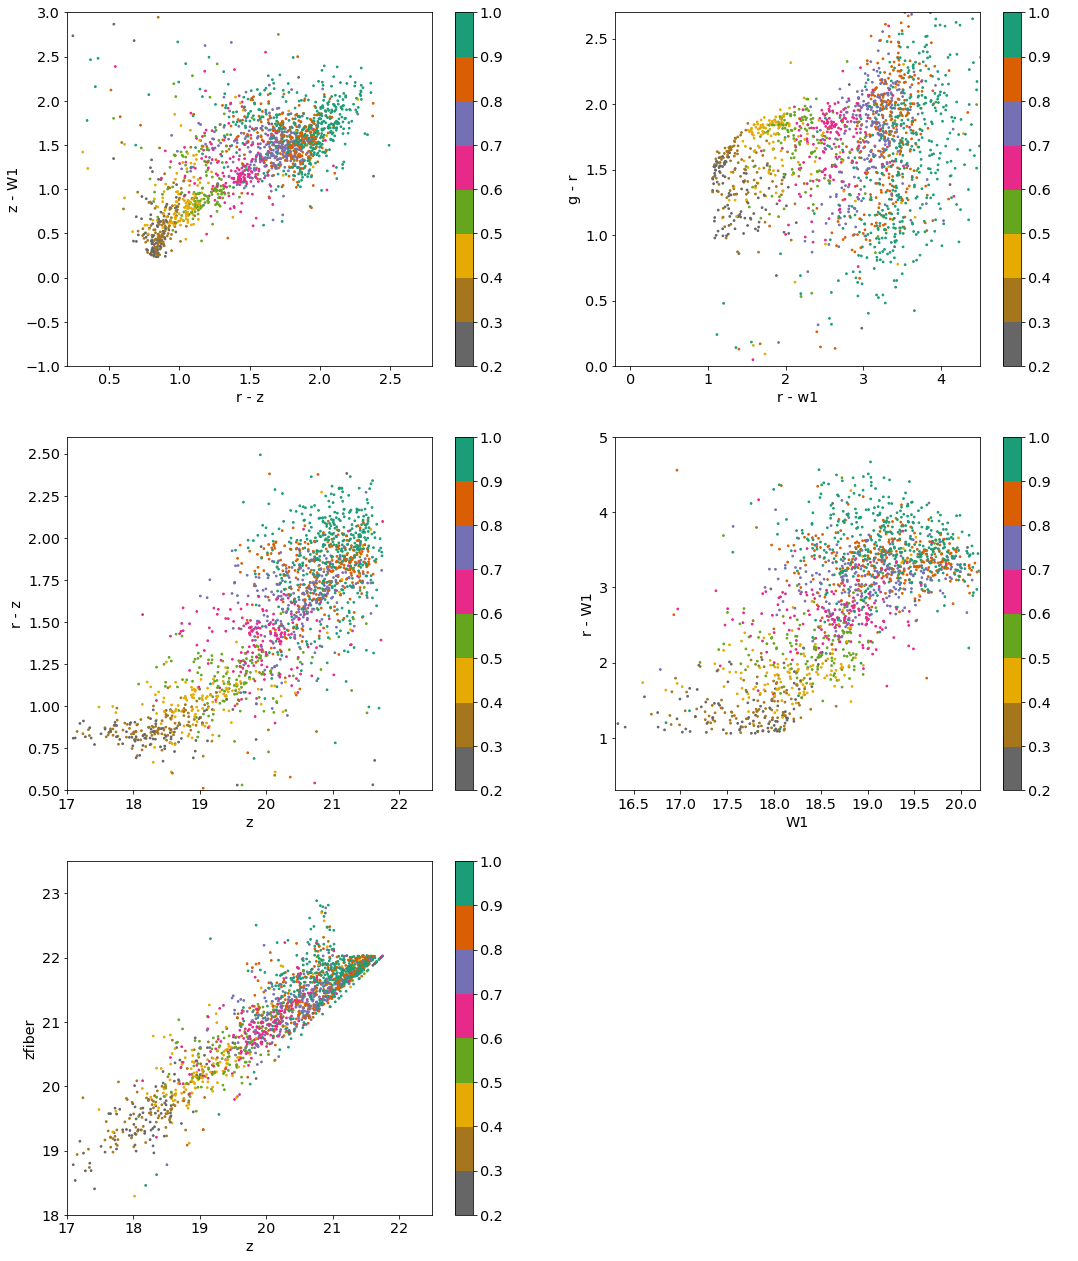

In [29]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

10


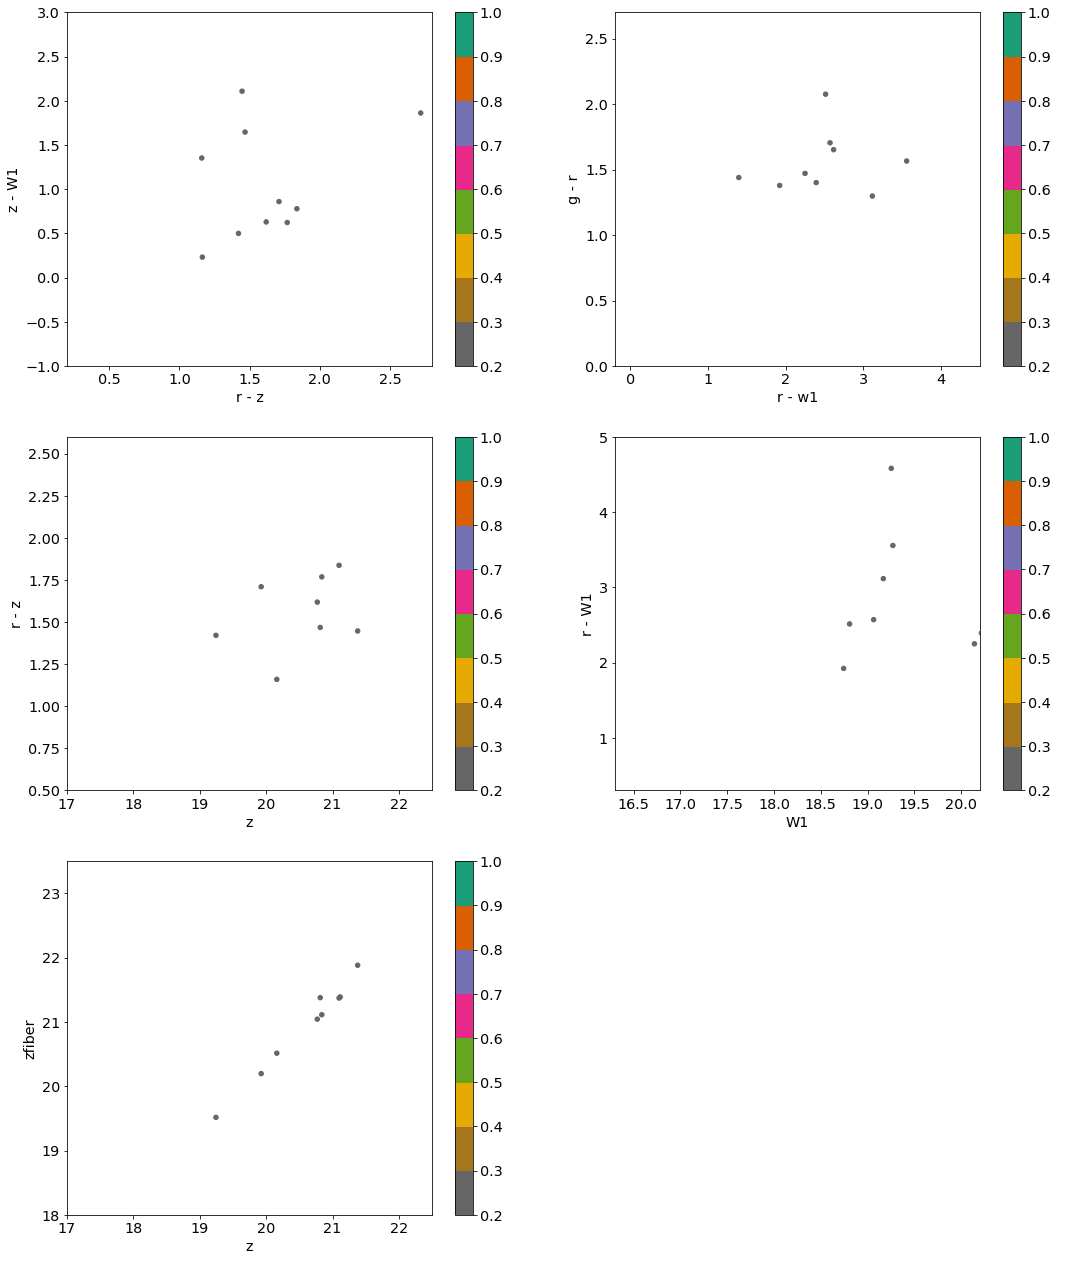

In [30]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

In [31]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39627670631226896,36362.73939551854,-1317.7936643364637 .. 0.0,-5.372710604089739e-06,2.2379202013981895e-06,0,7758,STAR,M,5,27548.018606047393,0,0,2,434,2434,1474,0,35.05384352700487,-4.7923116410533755,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,348.86023,-47.9213,0,3200,0.2652412495250299,1,PSF,0.46197674,2.220406,10.72021,1610.3171,743.8867,139.18456,0,,0.0,0.0,0.0,0.0,0.020624584,23.675903,24.178036,0.35984418,1.7295247,8.350215,4.3350196,16.13527,57.380722,0,0.0,0.0,0.0,0.0,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,348.866,-47.947,-0.003,-0.003125,0.0,0.0,8,0.005408326913195984,0.005396758286230726,1474,1474,1,23.33845,21.633919,19.924492,19.064234,19.041447,0.053941645,0.016512552,0.007906808,21.905184,20.195755,-5.372710604089739e-06
39627682698239034,19010.653957832765,-152.70015758226987 .. 0.0,-0.00011614658128754453,1.70285902269577e-05,0,7758,STAR,M,5,817.5570240726956,0,0,4,30,4030,2121,0,36.24237925562549,-4.235496909216657,0.0,0.0,2020.9487,5400.0,125829241,1,TGT,49.848007,89.11508,0,3200,0.548927455327992,1,PSF,0.031197298,0.29309866,3.583516,3408.5273,1872.7367,197.51434,0,,0.0,0.0,0.0,0.0,0.027307762,19.917841,16.282894,0.024253543,0.22786207,2.785913,0.269311,1.181051,4.9547133,0,0.0,0.0,0.0,0.0,S,125829241,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,49.825,89.118,-0.000125,0.001,0.0,0.0,8,0.00544288526426931,0.0052915026221291815,2121,2121,1,26.264708,23.832466,21.114227,19.251894,19.47067,0.5490345,0.07884022,0.01985598,24.10582,21.38758,-0.00011614658128754453


In [32]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

6


TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39627700788268603,15884.977203905582,150.48192095881973 .. -1.2179658660285941,0.8568988138236516,7.961788022710322e-05,0,7743,GALAXY,,10,644.3125633597374,0,0,4,391,4391,2214,0,35.89538472230812,-3.3863513191736003,0.0,0.0,2020.9487,5400.0,125829241,1,TGT,137.67448,304.11954,0,3200,0.6345890207698316,1,DEV,0.6987054,2.4307685,11.794486,790.93756,340.93735,40.527462,0,,0.0,0.0,0.0,0.0,0.023933763,64.600655,-15.125206,0.18870835,0.6565089,3.1854885,0.19092141,0.6595379,3.1885467,2816,4.0,1.6812377,-0.070198216,-0.20269693,S,125829241,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,137.672,304.093,-0.004,0.0015,0.0,0.0,8,0.007582875444051551,0.003774917217635375,2214,2214,1,22.889265,21.53564,19.820803,17.974407,nan,0.050890278,0.022280201,0.013318222,22.956898,21.24206,0.8568988138236516
39627706815480446,20614.82904946804,5.900690527062767e-05 .. 0.0,0.6222640353037696,5.920687570610937e-05,0,7750,QSO,,4,61.374428540468216,0,0,4,506,4506,2022,0,35.56339764145328,-3.321778759078391,0.0,0.0,2020.9487,5400.0,125829241,1,TGT,222.99832,323.77032,0,3200,0.8242168294179654,1,DEV,0.48068655,1.5863485,7.0127034,1273.7623,873.6596,105.28619,0,,0.0,0.0,0.0,0.0,0.025857916,73.40324,65.41322,0.21421148,0.70693487,3.1251168,0.21421187,0.70693755,3.1251361,256,4.0,0.7305191,0.22066009,-0.118747525,S,125829241,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,223.01,323.738,-0.0025,0.001,0.0,0.0,8,0.00897217922246318,0.004330127018922193,2022,2022,1,23.295345,21.999004,20.385286,17.835712,17.960836,0.058289967,0.021327022,0.0138972495,22.87655,21.262835,0.6222640353037696
39627706819679854,15644.03498339653,161.19142602571577 .. 2.7263839376631167,0.673389969864939,6.379773407363835e-05,0,7744,GALAXY,,10,1185.2010296583176,0,0,4,437,4437,2229,0,35.95336237832902,-3.2872625019427257,0.0,0.0,2020.9487,5400.0,125829241,1,TGT,123.565765,329.96512,0,3200,0.6446151903924807,1,SER,0.7216958,3.9318728,15.706566,701.5483,335.6938,43.347904,0,,0.0,0.0,0.0,0.0,0.025446841,44.510155,21.088326,0.22121936,1.2052258,4.814489,0.22409678,1.2139727,4.829393,768,6.0,1.6291959,0.053487655,0.17728178,S,125829241,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,123.557,329.938,-0.0011250000000000001,0.0022499999999999994,0.0,0.0,8,0.0076239

----------
# Delta-chi-square

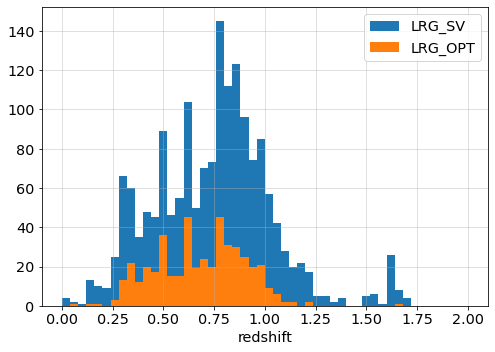

In [33]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['Z'][lrg_sv & mask_zwarn],  50, range=(0, 2.), label='LRG_SV')
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], 50, range=(0, 2.), label='LRG_OPT')
plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

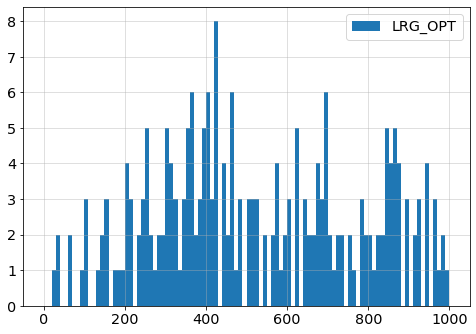

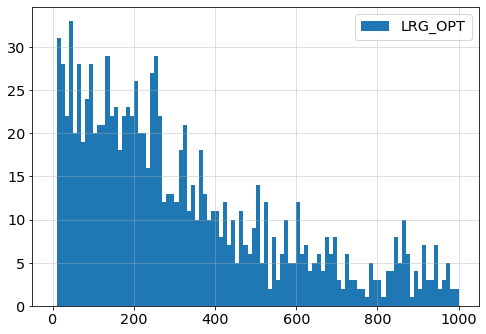

In [34]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

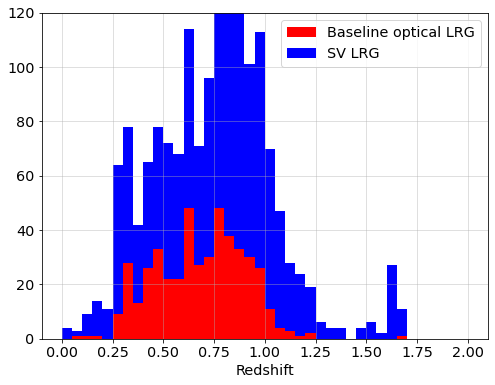

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)
plt.show()

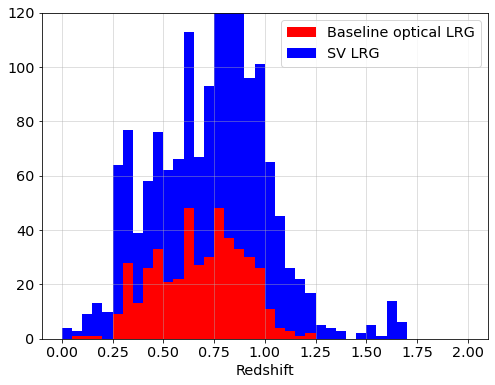

In [36]:
mask_dchi2 = zbest['DELTACHI2']>50

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)

plt.show()

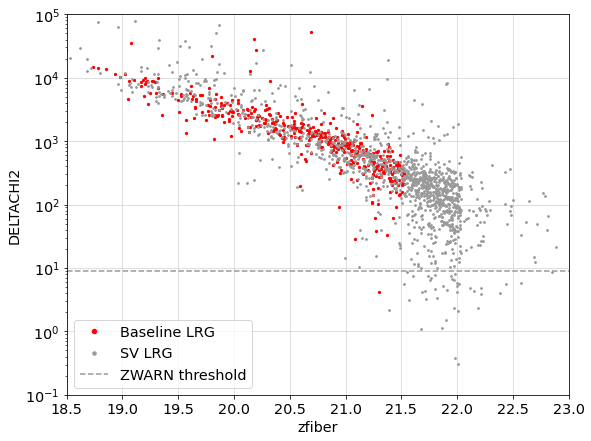

In [37]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

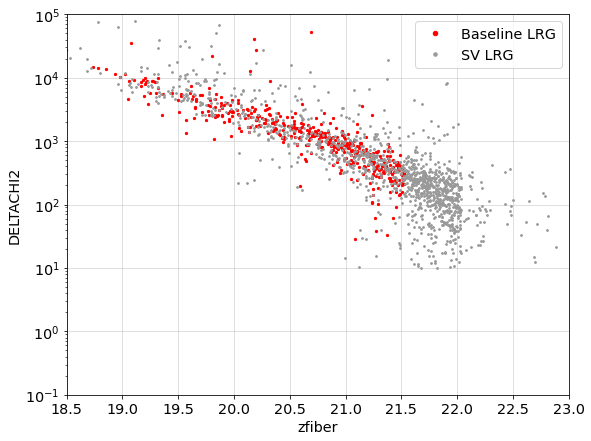

In [38]:
# Add ZWARN cut
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], 'b.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

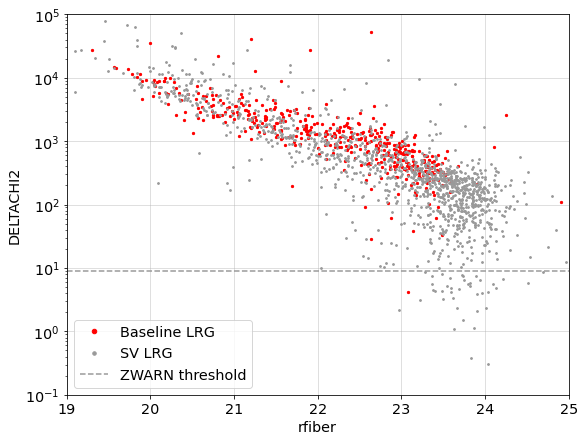

In [39]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()